# 第五章实验 2：多目标检测、画框与分割

本实验生成一张含多个随机几何目标的场景图，并执行完整检测流程：

**前景分割 → 连通域定位 → 边界框 → 形状特征分类 → 画框与类别标签。**

定位由像素级前景掩膜得到，因此在该数据集上预测框与真实框可以高度重合。
分类器沿用实验 1 的最近质心模型。整个 Notebook 无需联网和预训练权重。

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

SEED = 2026
rng = np.random.default_rng(SEED)
CLASS_NAMES = np.array(["circle", "square", "triangle"])
CLASS_COLORS = np.array([
    [0.90, 0.20, 0.20],
    [0.15, 0.65, 0.25],
    [0.15, 0.35, 0.90],
])

def polygon_mask(height, width, vertices):
    '''Vectorized ray-casting test: pixels inside an arbitrary polygon.'''
    yy, xx = np.mgrid[:height, :width]
    x = xx + 0.5
    y = yy + 0.5
    inside = np.zeros((height, width), dtype=bool)
    vertices = np.asarray(vertices, dtype=float)
    j = len(vertices) - 1
    for i in range(len(vertices)):
        xi, yi = vertices[i]
        xj, yj = vertices[j]
        crosses = ((yi > y) != (yj > y))
        x_cross = (xj - xi) * (y - yi) / (yj - yi + 1e-12) + xi
        inside ^= crosses & (x < x_cross)
        j = i
    return inside

def shape_mask(kind, size=64, center=None, scale=0.52, angle=0.0):
    '''Create a circle, square or triangle mask.'''
    cy, cx = center if center is not None else (size / 2, size / 2)
    yy, xx = np.mgrid[:size, :size]
    radius = size * scale / 2
    if kind == 0:
        return (xx - cx) ** 2 + (yy - cy) ** 2 <= radius ** 2

    count = 4 if kind == 1 else 3
    base = angle + (-np.pi / 4 if kind == 1 else -np.pi / 2)
    angles = base + np.arange(count) * 2 * np.pi / count
    vertices = np.column_stack([
        cx + radius * np.cos(angles),
        cy + radius * np.sin(angles),
    ])
    return polygon_mask(size, size, vertices)

def render_shape(kind, size=64, center=None, scale=0.52, angle=0.0,
                 color=None, noise=0.015, rng=rng):
    mask = shape_mask(kind, size, center, scale, angle)
    image = np.full((size, size, 3), 0.96, dtype=float)
    if color is None:
        color = CLASS_COLORS[kind]
    image[mask] = color
    image += rng.normal(0, noise, image.shape)
    return np.clip(image, 0, 1), mask

def foreground_mask(image):
    '''Separate colorful/dark objects from the nearly white background.'''
    return np.linalg.norm(image - 0.96, axis=2) > 0.20

def binary_perimeter(mask):
    padded = np.pad(mask, 1, constant_values=False)
    eroded = (
        padded[1:-1, 1:-1]
        & padded[:-2, 1:-1]
        & padded[2:, 1:-1]
        & padded[1:-1, :-2]
        & padded[1:-1, 2:]
    )
    return mask & ~eroded

def extract_features(image):
    '''Area ratio, circularity, extent and radial-distance variation.'''
    mask = foreground_mask(image)
    ys, xs = np.where(mask)
    area = float(mask.sum())
    perimeter = float(binary_perimeter(mask).sum())
    height = ys.max() - ys.min() + 1
    width = xs.max() - xs.min() + 1
    extent = area / (height * width)
    circularity = 4 * np.pi * area / max(perimeter ** 2, 1)
    cy, cx = ys.mean(), xs.mean()
    by, bx = np.where(binary_perimeter(mask))
    radii = np.sqrt((by - cy) ** 2 + (bx - cx) ** 2)
    radial_cv = radii.std() / max(radii.mean(), 1e-6)
    area_ratio = area / mask.size
    return np.array([area_ratio, circularity, extent, radial_cv])

def make_classification_dataset(
    samples_per_class=80, scale_range=(0.43, 0.62), rng=rng
):
    images, labels, features = [], [], []
    for label in range(3):
        for _ in range(samples_per_class):
            scale = rng.uniform(*scale_range)
            offset = rng.integers(-5, 6, size=2)
            angle = rng.uniform(-0.25, 0.25)
            color = rng.uniform(0.12, 0.88, size=3)
            if color.mean() > 0.72:
                color *= 0.65
            image, _ = render_shape(
                label,
                center=(32 + offset[0], 32 + offset[1]),
                scale=scale,
                angle=angle,
                color=color,
                rng=rng,
            )
            images.append(image)
            labels.append(label)
            features.append(extract_features(image))
    return np.asarray(images), np.asarray(labels), np.asarray(features)

class NearestCentroidClassifier:
    '''A tiny, interpretable classifier with one prototype per class.'''
    def fit(self, X, y):
        self.mean_ = X.mean(axis=0)
        self.scale_ = X.std(axis=0) + 1e-8
        Z = (X - self.mean_) / self.scale_
        self.classes_ = np.unique(y)
        self.centroids_ = np.vstack([Z[y == c].mean(axis=0) for c in self.classes_])
        return self

    def predict(self, X):
        Z = (X - self.mean_) / self.scale_
        distances = ((Z[:, None, :] - self.centroids_[None, :, :]) ** 2).sum(axis=2)
        return self.classes_[distances.argmin(axis=1)]

## 1. 训练轻量形状分类器

In [3]:
train_images, train_labels, train_features = make_classification_dataset(
    samples_per_class=90, scale_range=(0.76, 0.88)
)
classifier = NearestCentroidClassifier().fit(train_features, train_labels)
train_accuracy = (
    classifier.predict(train_features) == train_labels
).mean()
print(f"训练数据准确率: {train_accuracy:.2%}")

训练数据准确率: 100.00%


In [4]:
def connected_components(mask, min_area=40):
    '''Return bounding boxes (x1, y1, x2, y2) for 4-connected regions.'''
    height, width = mask.shape
    visited = np.zeros_like(mask, dtype=bool)
    boxes = []
    for y0, x0 in zip(*np.where(mask & ~visited)):
        if visited[y0, x0]:
            continue
        stack = [(y0, x0)]
        visited[y0, x0] = True
        xs, ys = [], []
        while stack:
            y, x = stack.pop()
            xs.append(x)
            ys.append(y)
            for ny, nx in ((y - 1, x), (y + 1, x), (y, x - 1), (y, x + 1)):
                if 0 <= ny < height and 0 <= nx < width:
                    if mask[ny, nx] and not visited[ny, nx]:
                        visited[ny, nx] = True
                        stack.append((ny, nx))
        if len(xs) >= min_area:
            boxes.append((min(xs), min(ys), max(xs) + 1, max(ys) + 1))
    return boxes

def make_detection_scene(size=192, rng=rng):
    image = np.full((size, size, 3), 0.96, dtype=float)
    truth = []
    # Fixed separated cells make the demonstration deterministic and avoid overlap.
    cells = [(48, 48), (48, 144), (144, 48), (144, 144)]
    labels = rng.choice(3, size=4, replace=True)
    for (cy, cx), label in zip(cells, labels):
        cy += int(rng.integers(-10, 11))
        cx += int(rng.integers(-10, 11))
        scale = rng.uniform(0.28, 0.38)
        angle = rng.uniform(-0.22, 0.22)
        color = rng.uniform(0.10, 0.82, size=3)
        if color.mean() > 0.68:
            color *= 0.60
        mask = shape_mask(label, size, center=(cy, cx), scale=scale, angle=angle)
        image[mask] = color
        ys, xs = np.where(mask)
        truth.append({
            "label": int(label),
            "box": (int(xs.min()), int(ys.min()), int(xs.max() + 1), int(ys.max() + 1)),
        })
    image += rng.normal(0, 0.012, image.shape)
    return np.clip(image, 0, 1), truth

def crop_to_square(image, box, output_size=64):
    x1, y1, x2, y2 = box
    crop = image[y1:y2, x1:x2]
    canvas = np.full((output_size, output_size, 3), 0.96, dtype=float)
    height, width = crop.shape[:2]
    scale = min((output_size - 10) / height, (output_size - 10) / width)
    new_h = max(1, int(round(height * scale)))
    new_w = max(1, int(round(width * scale)))
    yi = np.minimum((np.arange(new_h) / scale).astype(int), height - 1)
    xi = np.minimum((np.arange(new_w) / scale).astype(int), width - 1)
    resized = crop[yi[:, None], xi[None, :]]
    top = (output_size - new_h) // 2
    left = (output_size - new_w) // 2
    canvas[top:top + new_h, left:left + new_w] = resized
    return canvas

def detect_objects(image, classifier):
    mask = foreground_mask(image)
    boxes = connected_components(mask, min_area=120)
    detections = []
    for box in boxes:
        crop = crop_to_square(image, box)
        feature = extract_features(crop)
        label = int(classifier.predict(feature[None, :])[0])
        detections.append({"label": label, "box": box})
    return mask, detections

def box_iou(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    intersection = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    union = (ax2 - ax1) * (ay2 - ay1) + (bx2 - bx1) * (by2 - by1) - intersection
    return intersection / max(union, 1)

def draw_detections(ax, image, detections, title):
    ax.imshow(image)
    for item in detections:
        x1, y1, x2, y2 = item["box"]
        color = CLASS_COLORS[item["label"]]
        ax.add_patch(Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            fill=False, edgecolor=color, linewidth=2.5
        ))
        ax.text(
            x1, max(2, y1 - 3), CLASS_NAMES[item["label"]],
            color="white", fontsize=10,
            bbox={"facecolor": color, "alpha": 0.9, "pad": 2, "edgecolor": "none"},
        )
    ax.set_title(title)
    ax.axis("off")

## 2. 生成场景并检测所有目标

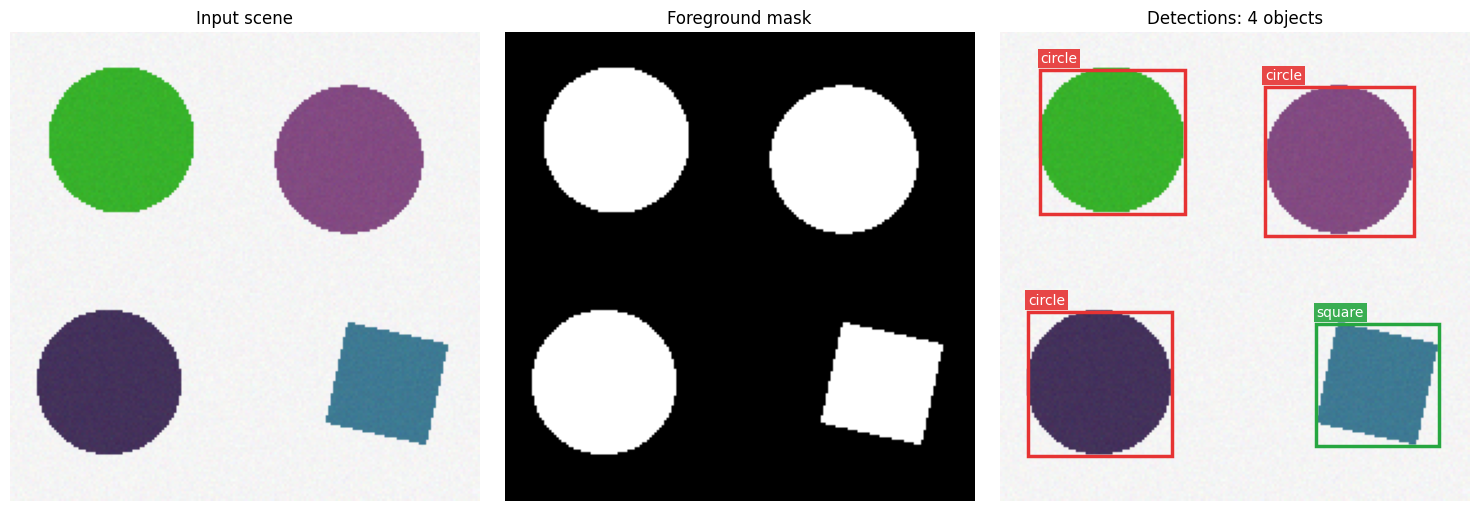

In [5]:
scene, truth = make_detection_scene()
foreground, detections = detect_objects(scene, classifier)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(scene)
axes[0].set_title("Input scene")
axes[0].axis("off")
axes[1].imshow(foreground, cmap="gray")
axes[1].set_title("Foreground mask")
axes[1].axis("off")
draw_detections(
    axes[2], scene, detections,
    f"Detections: {len(detections)} objects"
)
plt.tight_layout()
plt.show()

## 3. 用 IoU 和类别准确率评价检测结果

In [6]:
matched_ious = []
matched_correct = []
for target in truth:
    best = max(detections, key=lambda det: box_iou(target["box"], det["box"]))
    matched_ious.append(box_iou(target["box"], best["box"]))
    matched_correct.append(target["label"] == best["label"])

print("每个目标的 IoU:", np.round(matched_ious, 3))
print(f"平均 IoU: {np.mean(matched_ious):.3f}")
print(f"类别准确率: {np.mean(matched_correct):.2%}")
print(f"真实目标数 / 检出目标数: {len(truth)} / {len(detections)}")

每个目标的 IoU: [1. 1. 1. 1.]
平均 IoU: 1.000
类别准确率: 100.00%
真实目标数 / 检出目标数: 4 / 4


## 4. 批量测试不同场景

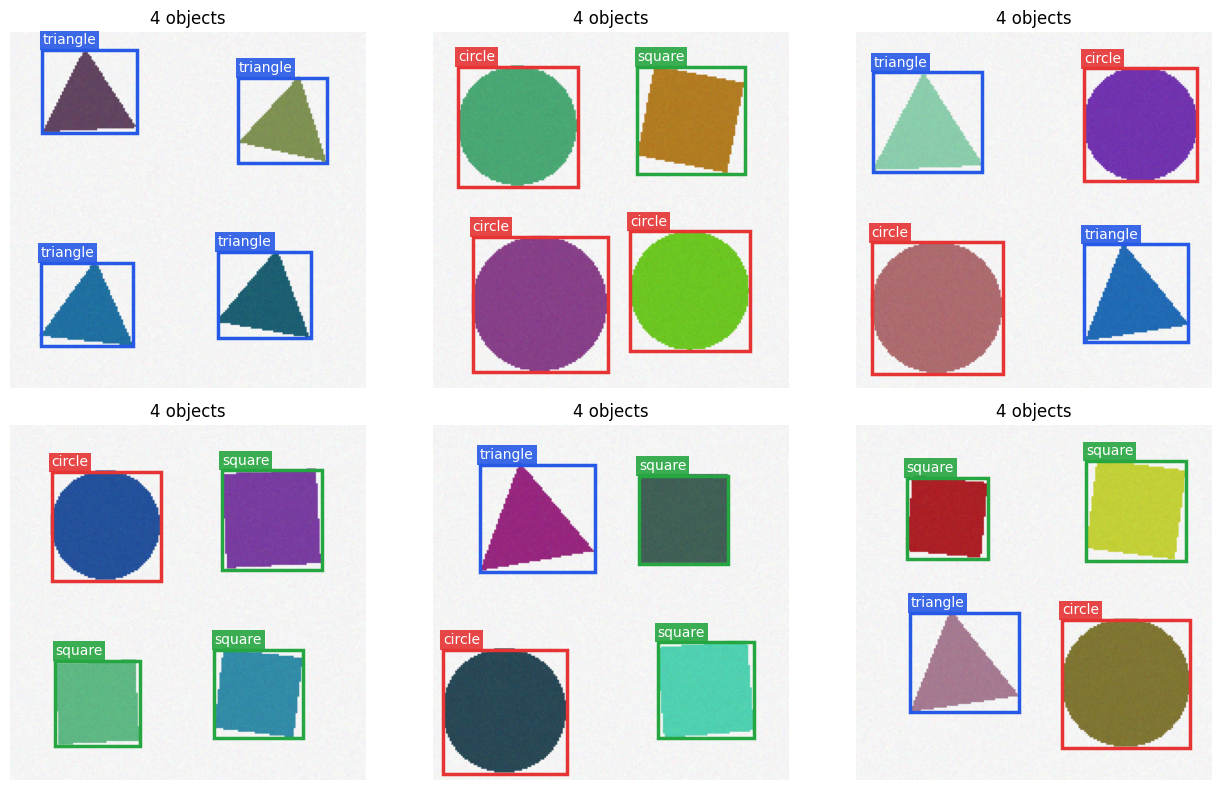

批量测试平均 IoU: 1.000
批量测试类别准确率: 100.00%


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
all_ious, all_correct = [], []
for ax in axes.ravel():
    test_scene, test_truth = make_detection_scene()
    _, test_det = detect_objects(test_scene, classifier)
    draw_detections(ax, test_scene, test_det, f"{len(test_det)} objects")
    for target in test_truth:
        best = max(test_det, key=lambda det: box_iou(target["box"], det["box"]))
        all_ious.append(box_iou(target["box"], best["box"]))
        all_correct.append(target["label"] == best["label"])
plt.tight_layout()
plt.show()

print(f"批量测试平均 IoU: {np.mean(all_ious):.3f}")
print(f"批量测试类别准确率: {np.mean(all_correct):.2%}")